In [30]:
import sys
import os

import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

sys.path.append('../../official_github')
from dataset.mnist import load_mnist
from multi_layer_net_extend import MultiLayerNetExtend
from common.optimizer import SGD, Adam

In [31]:
# 데이터 읽기
(x_train, t_train), (x_test, t_test) = \
    load_mnist(normalize=True, one_hot_label=False)

In [32]:
print(x_train.shape)
print(np.max(x_train))
print(t_train.shape)

(60000, 784)
1.0
(60000,)


In [33]:
network_dict = {
                'step': MultiLayerNetExtend(input_size=784, hidden_size_list=[100], output_size=10, activation='step', weight_init_std=0.01),
                'sigmoid': MultiLayerNetExtend(input_size=784, hidden_size_list=[100], output_size=10, activation='sigmoid', weight_init_std=0.01),
                'tanh': MultiLayerNetExtend(input_size=784, hidden_size_list=[100], output_size=10, activation='tanh', weight_init_std=0.01),
                'relu': MultiLayerNetExtend(input_size=784, hidden_size_list=[50], output_size=10, activation='relu', weight_init_std=0.01),
                'leaky': MultiLayerNetExtend(input_size=784, hidden_size_list=[100], output_size=10, activation='leaky', weight_init_std=0.01),
                }

In [34]:
network_dict['relu'].params.keys()

dict_keys(['W1', 'b1', 'W2', 'b2'])

In [35]:
# 하이퍼 파라메터
iters_num = 10_000  # 반복횟수
train_size = x_train.shape[0]
batch_size = 100  # 미니배치 크기
learning_rate = 0.1
iter_per_epoch = max(train_size / batch_size, 1)

In [36]:
output_dict = {}
for key, network in network_dict.items():

    # optimizer = SGD(lr=learning_rate)
    
    output_dict[f'{key} train acc'] = []
    output_dict[f'{key} test acc'] = []
    
    print(f'=== {key} network training start ===')
    for i in range(iters_num):
        # print(i)
        # 미니배치 획득
        batch_mask = np.random.choice(train_size, batch_size)
        x_batch = x_train[batch_mask]
        t_batch = t_train[batch_mask]

        # 오차역전파법으로 기울기 계산
        grad = network.gradient(x_batch, t_batch)

        # 매개변수 갱신
        for param in ('W1', 'b1', 'W2', 'b2'):
            network.params[param] -= learning_rate * grad[param]

        # 학습 경과 기록
        loss = network.loss(x_batch, t_batch)
        # print('loss:', loss)

        # 1에폭 당 정확도 계산
        if i % iter_per_epoch == 0:
            train_acc = network.accuracy(x_train, t_train)
            test_acc = network.accuracy(x_test, t_test)
            output_dict[f'{key} train acc'].append(train_acc)
            output_dict[f'{key} test acc'].append(test_acc)
            print(f'--- {key} result report ---')
            print("train acc, test acc | " + str(train_acc) + ", " + str(test_acc))
        
    print('='*10)
    print('\n\n')


=== step network training start ===


--- step result report ---
train acc, test acc | 0.11715, 0.1174
--- step result report ---
train acc, test acc | 0.7869833333333334, 0.7923
--- step result report ---
train acc, test acc | 0.7961333333333334, 0.7987
--- step result report ---
train acc, test acc | 0.80405, 0.8051
--- step result report ---
train acc, test acc | 0.80595, 0.8098
--- step result report ---
train acc, test acc | 0.8080833333333334, 0.8078
--- step result report ---
train acc, test acc | 0.8109333333333333, 0.8119
--- step result report ---
train acc, test acc | 0.80965, 0.8109
--- step result report ---
train acc, test acc | 0.8104, 0.8136
--- step result report ---
train acc, test acc | 0.81095, 0.8134
--- step result report ---
train acc, test acc | 0.8101333333333334, 0.8123
--- step result report ---
train acc, test acc | 0.81155, 0.8104
--- step result report ---
train acc, test acc | 0.8132666666666667, 0.8148
--- step result report ---
train acc, test acc | 0.81285, 0.8137
--- step result report --

step train acc
step test acc
sigmoid train acc
sigmoid test acc
tanh train acc
tanh test acc
relu train acc
relu test acc
leaky train acc
leaky test acc


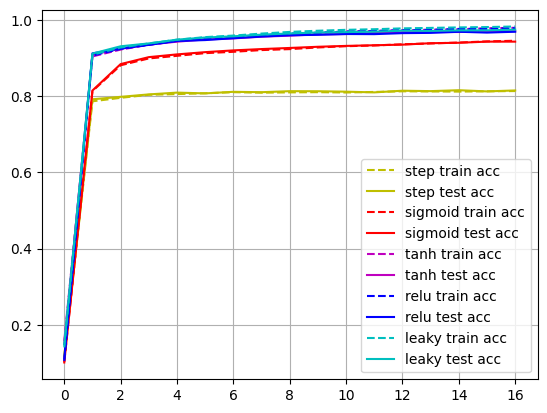

In [37]:
for k, v in output_dict.items():
    print(k)
    
    x = range(len(v))
    
    if k.startswith('step'):
        color_code = 'y'
    elif k.startswith('sigmoid'):
        color_code = 'r'
    elif k.startswith('tanh'):
        color_code = 'm'
    elif k.startswith('relu'):
        color_code = 'b'
    elif k.startswith('leaky'):
        color_code = 'c'

    if 'train' in k:
        linestyle = 'dashed'
    else:
        linestyle = 'solid'
    
    plt.plot(x, v, linestyle=linestyle, color=color_code, label = k)
        
    
plt.legend()
plt.grid()